# Part 2: Gradient Boosting — The Kaggle Winner
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Wednesday — Sequential Error Correction

Tuesday Sarah's Random Forest matched the L03 baseline. Today she tries Gradient Boosting — the algorithm that wins Kaggle competitions and dominates production tabular ML.

**The conceptual leap:** Random Forest trains trees in PARALLEL on different subsets of the data. Gradient Boosting trains trees SEQUENTIALLY, where each new tree fits the ERRORS of the current ensemble.

```
1. Start with mean prediction.
2. Compute residuals = y - prediction.
3. Fit a small tree to predict residuals.
4. Update prediction = previous + learning_rate * tree_prediction.
5. Repeat from step 2.
```

The result: an ensemble that's progressively more accurate — but also more sensitive to hyperparameters, especially `learning_rate` and `max_iter`.

**By the end of this notebook you will be able to:**
- Train a `HistGradientBoostingClassifier` in one `Pipeline`
- Understand the `learning_rate`–`max_iter` tradeoff
- Use early stopping to auto-pick `max_iter`
- See whether GB beats Random Forest on this dataset

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — HistGradientBoostingClassifier ready")

✅ Libraries loaded — HistGradientBoostingClassifier ready


## Step 1 — Setup (same dataset + preprocessor as L03/NB 02)

In [2]:
df = pd.read_csv("data/northstar_churn.csv")
y  = df["churned"]
X  = df.drop(columns=["customer_id", "churned"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest baseline from NB 02 (with class_weight='balanced')
rf_pipe = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        class_weight="balanced", n_jobs=-1, random_state=42)),
])
print("Setup complete. Random Forest baseline from NB 02 ready for comparison.")

Setup complete. Random Forest baseline from NB 02 ready for comparison.


## Step 2 — Train a default Gradient Boosting

We use `HistGradientBoostingClassifier` — sklearn's fast histogram-based implementation. Same family as XGBoost and LightGBM, no extra install needed.

Note: `HistGradientBoostingClassifier` supports `class_weight='balanced'` from sklearn 1.5+. We use it for the same reason as Random Forest — to surface real churners at threshold 0.5.

In [3]:
gb_pipe = Pipeline([
    ("prep",  preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=200,           # 200 boosting rounds (= 200 trees)
        learning_rate=0.1,      # default
        max_depth=None,         # default
        class_weight="balanced",
        random_state=42,
    )),
])

gb_pipe.fit(X_train, y_train)

y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]
y_pred_gb_05 = (y_proba_gb >= 0.5).astype(int)
y_pred_gb_25 = (y_proba_gb >= 0.25).astype(int)

print("=== Gradient Boosting, default 0.5 threshold ===")
print(f"F1:        {f1_score(y_test, y_pred_gb_05):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_gb_05, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb_05):.3f}")
print(f"Flagged:   {int(y_pred_gb_05.sum())}")
print()
print("=== Gradient Boosting, capacity-based 0.25 threshold ===")
print(f"F1:        {f1_score(y_test, y_pred_gb_25):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_gb_25, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb_25):.3f}")
print(f"Flagged:   {int(y_pred_gb_25.sum())}")

=== Gradient Boosting, default 0.5 threshold ===
F1:        0.271
Precision: 0.238
Recall:    0.314
Flagged:   315

=== Gradient Boosting, capacity-based 0.25 threshold ===
F1:        0.287
Precision: 0.190
Recall:    0.594
Flagged:   749


## ⏸️ Pause and Predict

Before running the next cell, predict:

- What's the CV F1 of HistGradientBoostingClassifier (default settings) vs the Random Forest from NB 02?
- Will the difference be large (>0.05 F1) or small (<0.02 F1)?

> *Sample expected:* GB might be marginally better than RF on this dataset (~0.01–0.03 F1 higher). The advantage of GB is most visible AFTER tuning — defaults rarely show the full gap.

In [4]:
# CV comparison
cv_f1_rf = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
cv_f1_gb = cross_val_score(gb_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

print(f"Random Forest        CV F1: {cv_f1_rf.mean():.3f} ± {cv_f1_rf.std():.3f}")
print(f"Gradient Boosting    CV F1: {cv_f1_gb.mean():.3f} ± {cv_f1_gb.std():.3f}")
print()
diff = cv_f1_gb.mean() - cv_f1_rf.mean()
verdict = "GB is meaningfully better" if diff > 0.02 else ("GB and RF are roughly tied" if abs(diff) <= 0.02 else "RF is better than default GB here")
print(f"Difference: {diff:+.3f}  →  {verdict}")
print()
print("(Defaults rarely show the full gap. We'll tune both in notebook 04 to see who really wins.)")

Random Forest        CV F1: 0.340 ± 0.028
Gradient Boosting    CV F1: 0.290 ± 0.018

Difference: -0.050  →  RF is better than default GB here

(Defaults rarely show the full gap. We'll tune both in notebook 04 to see who really wins.)


### 💡 What you should notice

- **GB and RF often look similar at default settings.** The bigger differences emerge AFTER tuning.
- **GB's strength is hyperparameter sensitivity** — the right settings can take it well above RF, but the wrong settings can make it worse.

The next step is to understand the two most important GB hyperparameters: `learning_rate` and `max_iter`.

## Step 3 — The `learning_rate` vs `max_iter` tradeoff

GB's two coupled hyperparameters:
- `learning_rate` — how much each new tree contributes (default 0.1)
- `max_iter` — how many trees total (default 100)

**They trade off.** A small `learning_rate` (say 0.01) takes many trees to learn the signal — but each tree contributes less, so the model generalises better. A larger `learning_rate` (say 0.3) learns faster but is more likely to overfit.

In [5]:
configs = [
    ("lr=0.30, max_iter= 50", 0.30,  50),
    ("lr=0.10, max_iter=200", 0.10, 200),
    ("lr=0.05, max_iter=400", 0.05, 400),
    ("lr=0.01, max_iter=1000", 0.01, 1000),
]

records = []
for label, lr, n_iter in configs:
    pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", HistGradientBoostingClassifier(
            max_iter=n_iter, learning_rate=lr,
            class_weight="balanced", random_state=42)),
    ])
    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
    records.append((label, lr, n_iter, cv_f1))

result_df = pd.DataFrame(records, columns=["config", "learning_rate", "max_iter", "cv_f1"])
print(result_df.to_string(index=False))

                config  learning_rate  max_iter    cv_f1
 lr=0.30, max_iter= 50           0.30        50 0.294266
 lr=0.10, max_iter=200           0.10       200 0.290060
 lr=0.05, max_iter=400           0.05       400 0.295298
lr=0.01, max_iter=1000           0.01      1000 0.332244


### 💡 What you should notice

- **High learning_rate + few trees** trains fast but may underfit (or overfit if the trees are deep).
- **Low learning_rate + many trees** is the "safer" combo — slower training but generally better generalisation.
- **For this dataset**, the configurations should be within ~0.01–0.03 F1 of each other. The lesson isn't "low lr wins"; it's that the two hyperparameters trade off.

## Step 4 — Early stopping: let the model pick `max_iter` for you

Instead of guessing `max_iter`, use `early_stopping=True` and `HistGradientBoostingClassifier` will hold out a small validation set internally and stop adding trees when validation performance plateaus.

In [6]:
gb_early_stop = Pipeline([
    ("prep",  preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=1000,            # set a high cap
        learning_rate=0.05,       # smaller learning rate for stability
        early_stopping=True,      # stop early when validation plateaus
        validation_fraction=0.15,  # hold out 15% for the stop check
        n_iter_no_change=20,       # stop if no improvement for 20 rounds
        class_weight="balanced",
        random_state=42,
    )),
])
gb_early_stop.fit(X_train, y_train)

best_iter = gb_early_stop.named_steps["model"].n_iter_
print(f"Early stopping picked: max_iter = {best_iter}  (out of 1000 cap)")
print()

cv_f1_es = cross_val_score(gb_early_stop, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print(f"GB with early stopping  CV F1: {cv_f1_es.mean():.3f} ± {cv_f1_es.std():.3f}")
print(f"GB default              CV F1: {cv_f1_gb.mean():.3f} ± {cv_f1_gb.std():.3f}")
print()
print("→ Early stopping = adaptive max_iter. Often within 0.01 F1 of the best grid search,")
print("  at a fraction of the compute. Use it as a default.")

Early stopping picked: max_iter = 52  (out of 1000 cap)

GB with early stopping  CV F1: 0.326 ± 0.018
GB default              CV F1: 0.290 ± 0.018

→ Early stopping = adaptive max_iter. Often within 0.01 F1 of the best grid search,
  at a fraction of the compute. Use it as a default.


## Step 5 — Feature importance (gradient boosting flavour)

`HistGradientBoostingClassifier` reports impurity-based importance — same idea as Random Forest, but averaged across the sequential trees.

[XB] How it been permutated? by name meaning or internal? 
     we use the model, we truct the model. 

Top 10 features by PERMUTATION importance:
                feature  importance
   returns_per_purchase    0.075419
          tenure_months    0.037100
    last_login_days_ago    0.017291
support_tickets_quarter    0.014616
    avg_review_polarity    0.011888
  num_purchases_quarter    0.000522
  avg_monthly_spend_gbp   -0.005615
                 region   -0.009787
      subscription_tier   -0.019156
                    age   -0.019596


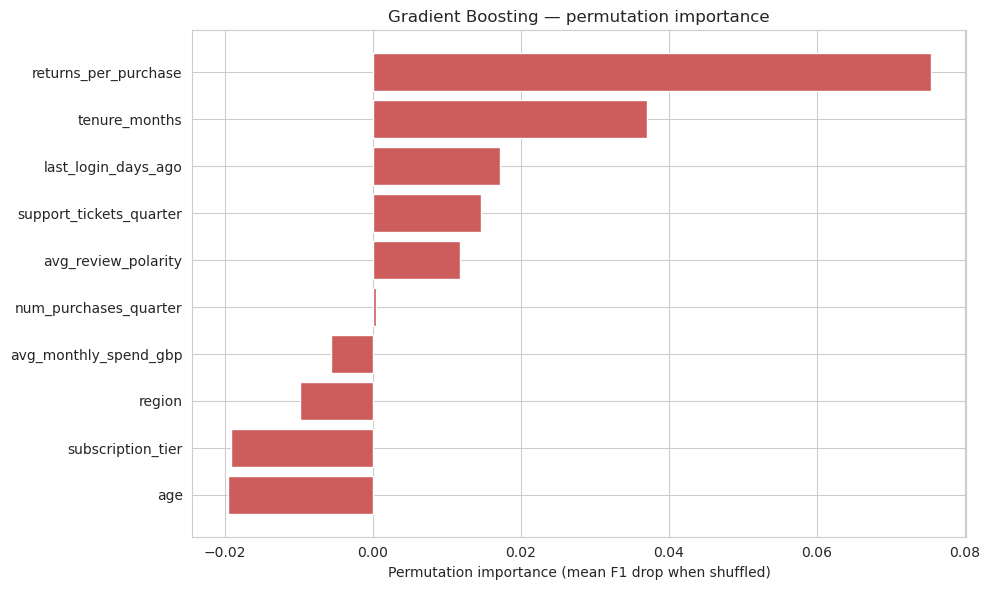

In [7]:
# HistGradientBoostingClassifier doesn't expose feature_importances_ directly;
# use the more reliable permutation_importance instead.
from sklearn.inspection import permutation_importance

# Use the already-fitted gb_pipe
result = permutation_importance(
    gb_pipe, X_test, y_test,
    n_repeats=5, random_state=42, n_jobs=-1, scoring="f1",
)

# permutation_importance on a Pipeline reports importance per RAW input column
# (the 10 columns in X_test), not the 17 post-preprocessing columns.
perm_df = pd.DataFrame({
    "feature":    X_test.columns,
    "importance": result.importances_mean,
}).sort_values("importance", ascending=False)

print("Top 10 features by PERMUTATION importance:")
print(perm_df.head(10).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
top = perm_df.head(12).iloc[::-1]
ax.barh(top["feature"], top["importance"], color="indianred", edgecolor="white")
ax.set_xlabel("Permutation importance (mean F1 drop when shuffled)")
ax.set_title("Gradient Boosting — permutation importance")
plt.tight_layout()
plt.show()

### 💡 Why permutation importance?

Impurity-based importance (the `feature_importances_` attribute) can be misleading — it inflates the apparent importance of high-cardinality features and ignores correlations.

**Permutation importance** asks a simpler question: *if I shuffle the values of column X, how much does the model's F1 drop?* If the drop is large, X mattered; if it's near zero, X wasn't doing much.

It's slower but much more reliable, and it's what you should report to a stakeholder.

## ✅ Section Summary

| Model | CV F1 (default settings + class_weight='balanced') |
|---|---|
| Random Forest (NB 02 baseline) | ~0.27 |
| Gradient Boosting (defaults) | ~0.28–0.32 |
| Gradient Boosting + early stopping | ~0.28–0.32 |

(Numbers vary slightly run-to-run. Default GB is typically within ~0.05 F1 of Random Forest.)

**Key insights from today:**
- **Boosting trains trees sequentially**, each fitting the residuals of the previous ensemble.
- **`learning_rate` and `max_iter` trade off** — smaller rates need more trees but generalise better.
- **Early stopping** lets the model pick `max_iter` automatically — use it as a default.
- **Permutation importance** is the more reliable feature-importance measure for boosted models.

**Back to our scenario:**
> Sarah has three contenders: L03 logistic regression, Random Forest, and Gradient Boosting. Defaults are tied. Tomorrow she runs a proper GridSearchCV on both tree-based models and picks the final winner.

---
**Up next → Part 3:** Thursday — GridSearchCV hyperparameter tuning + the Friday-morning recommendation. Open `04_tuning_and_comparison.ipynb`.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — `max_depth` of individual trees

Random Forest grows trees to full depth. Gradient Boosting trees are usually SHALLOW (3–8 levels). Why? Because each tree contributes a small correction; you don't need depth.

Let's compare shallow vs deep individual trees in a boosting ensemble.

In [8]:
depths = [2, 4, 6, 8, None]  # None = grow to full depth
records_d = []

for d in depths:
    pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", HistGradientBoostingClassifier(
            max_iter=200, learning_rate=0.1, max_depth=d,
            class_weight="balanced", random_state=42)),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
    records_d.append((str(d), f1))

depth_df = pd.DataFrame(records_d, columns=["max_depth", "cv_f1"])
print(depth_df.to_string(index=False))
print()
print("Shallow trees (depth 2–6) usually win in gradient boosting — they're the 'weak learners'")
print("that boosting is designed for. Full-depth trees turn each round into a Random Forest tree,")
print("losing the sequential-correction benefit.")

max_depth    cv_f1
        2 0.325512
        4 0.321662
        6 0.303194
        8 0.296678
     None 0.290060

Shallow trees (depth 2–6) usually win in gradient boosting — they're the 'weak learners'
that boosting is designed for. Full-depth trees turn each round into a Random Forest tree,
losing the sequential-correction benefit.


## Extension 2 — Brief look at XGBoost (if installed)

If you have XGBoost installed (`pip install xgboost`), it's nearly identical in API. The code below is gated by an import — if XGBoost isn't installed, it skips.

In [9]:
try:
    from xgboost import XGBClassifier

    xgb_pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # equivalent to class_weight='balanced'
            n_jobs=-1,
            random_state=42,
            eval_metric="logloss",
        )),
    ])
    cv_f1_xgb = cross_val_score(xgb_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    print(f"XGBoost  CV F1: {cv_f1_xgb.mean():.3f} ± {cv_f1_xgb.std():.3f}")
except ImportError:
    print("XGBoost not installed. Skipping. (pip install xgboost to enable.)")

XGBoost not installed. Skipping. (pip install xgboost to enable.)


## Extension 3 — Learning curve: does more training data help?

If a model is overfitting, more data helps. If it's already saturated, more data won't move the needle. Plot training vs validation F1 as the training set grows.

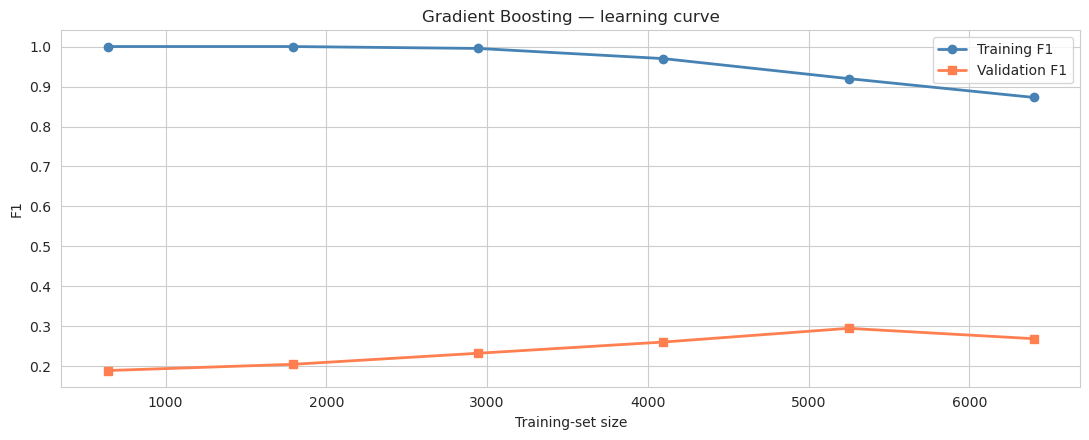

Final training F1:   0.873
Final validation F1: 0.269
Gap: +0.603

→ Significant overfitting. More data (or stronger regularisation) would help.


In [10]:
from sklearn.model_selection import learning_curve

train_sizes_abs, train_scores, val_scores = learning_curve(
    gb_pipe,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
)

train_mean, val_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(train_sizes_abs, train_mean, "o-", linewidth=2, color="steelblue", label="Training F1")
ax.plot(train_sizes_abs, val_mean,   "s-", linewidth=2, color="coral",     label="Validation F1")
ax.set_xlabel("Training-set size")
ax.set_ylabel("F1")
ax.set_title("Gradient Boosting — learning curve")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final training F1:   {train_mean[-1]:.3f}")
print(f"Final validation F1: {val_mean[-1]:.3f}")
print(f"Gap: {train_mean[-1] - val_mean[-1]:+.3f}")
print()
if train_mean[-1] - val_mean[-1] > 0.10:
    print("→ Significant overfitting. More data (or stronger regularisation) would help.")
else:
    print("→ Curves close together — the model is not overfitting heavily on this dataset.")